Let's talk about the goals of this jupyter notebook

* Establish a normalized 0-1 score of roughness for each image for benchmarking
* Compare to plain multimodal LLM normalized output for all images
* Select multiple train-test splits for fine-tuning such a LLM and compare to human rankings on testing subset

ONCE ERROR FROM ABOVE IS NOW ACCEPTABLE

* Download online dataset & Establish a pipeline for taking images from a large data database and feeding them to a LLM for evaluation in the Normalized 0-1 score
* Use resulting scores to train a CNN, KNN, and SVM

## Plan for Goal 1

1. Load the anonymized survey rankings from the JSON file.
2. Treat each survey row as a set of relative rankings, where lower ranks indicate smoother surfaces and higher ranks indicate rougher ones.
3. Aggregate the ranks for each image by computing the mean rank across all survey responses.
4. Convert those mean ranks into a normalized 0-1 roughness score using min-max scaling.
5. Save the resulting table to a CSV file so it can be reused for benchmarking, model training, and later comparison with LLM outputs.


Saved 53 image scores to ..\data\normalized_roughness_scores.csv


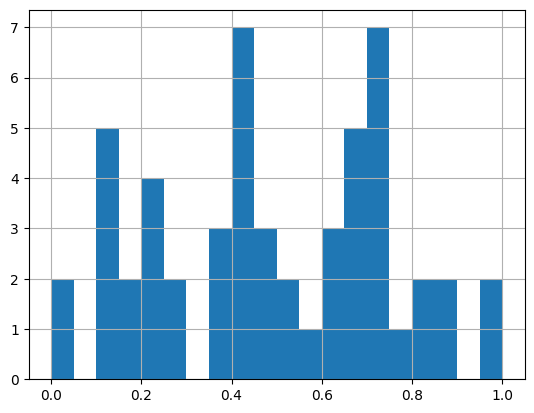

In [22]:
import json
from pathlib import Path

import pandas as pd


def simple_mean_roughness_score():

    survey_path = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
    output_path = Path("..") / "data" / "normalized_roughness_scores.csv"

    with survey_path.open(encoding="utf-8") as f:
        surveys = json.load(f)

    rank_lists = {}

    for survey in surveys:
        for image_name, rank in survey.items():
            if image_name in {"index", "timestamp", "name", "gender"}:
                continue
            rank_lists.setdefault(image_name, []).append(int(rank))

    score_table = pd.DataFrame(
        {
            "image": list(rank_lists.keys()),
            "rank_count": [len(ranks) for ranks in rank_lists.values()],
            "mean_rank": [sum(ranks) / len(ranks) for ranks in rank_lists.values()],
            "min_rank": [min(ranks) for ranks in rank_lists.values()],
            "max_rank": [max(ranks) for ranks in rank_lists.values()],
        }
    )

    if score_table["mean_rank"].nunique() > 1:
        min_rank = score_table["mean_rank"].min()
        max_rank = score_table["mean_rank"].max()
        score_table["normalized_roughness_score"] = (
            (score_table["mean_rank"] - min_rank) / (max_rank - min_rank)
        )
    else:
        score_table["normalized_roughness_score"] = 0.5

    score_table = score_table.sort_values("normalized_roughness_score", ascending=False).reset_index(drop=True)
    score_table.to_csv(output_path, index=False)

    print(f"Saved {len(score_table)} image scores to {output_path}")
    score_table[["image", "mean_rank", "normalized_roughness_score"]].head(15)
    #create a histogram of the normalized roughness scores 
    score_table["normalized_roughness_score"].hist(bins=20)

simple_mean_roughness_score()


In [23]:
!pip install choix

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ok so, now comes the second part where I take data from a multimodal LLM, get it's BT scores and in the end we'll have a nice lil figure with the 3 buckets for each of the different categories(least rough, mid rough, most rough), and then we'll move from there into developing the overall syntethic dataset.

 ### Part II
 

In [26]:
!pip install dotenv

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from google import genai

def basic_api_test():
    client_test = genai.Client(api_key=api_key)
    interaction = client_test.models.generate_content(
        model="gemini-3.6-flash",
        contents="Explain how AI works in a few words"
    )
    print(interaction.text)

    print(f"Prompt Tokens: {interaction.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {interaction.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {interaction.usage_metadata.total_token_count}")
basic_api_test()

AI works by **finding patterns in vast amounts of data** and using those patterns to **predict answers, solve problems, or create content.** 

In short: **Data in $\rightarrow$ Pattern learned $\rightarrow$ Smart output out.**
Prompt Tokens: 9
Output Tokens: 48
Total Tokens: 553


In [51]:
def rank_images_gemini(image_paths, labels=None,GEMINI_MODEL="gemini-3.6-flash"):
    labels = labels or [chr(65 + i) for i in range(len(image_paths))]

    parts = [types.Part.from_text(text=(
        "You will see several texture images, each preceded by its label. "
        "Rank them from roughest to smoothest based on visual texture. "
        "Respond ONLY with a JSON array of labels in order from roughest "
        "to smoothest, e.g. [\"C\", \"A\", \"E\", \"B\", \"D\"]. No other text."
    ))]

    for label, path in zip(labels, image_paths):
        mime_type, _ = mimetypes.guess_type(str(path))
        parts.append(types.Part.from_text(text=f"Image {label}:"))
        with open(path, "rb") as f:
            image_bytes = f.read()
        parts.append(types.Part.from_bytes(data=image_bytes, mime_type=mime_type or "image/jpeg"))

    response = client.models.generate_content(
        model=GEMINI_MODEL,
        contents=parts,
        config=types.GenerateContentConfig(
                    temperature=0.1,
                    response_mime_type="application/json",
                    response_schema=list[str]
                )
    )

    print(f"Prompt Tokens: {response.usage_metadata.prompt_token_count}")
    print(f"Output Tokens: {response.usage_metadata.candidates_token_count}")
    print(f"Total Tokens: {response.usage_metadata.total_token_count}")
    return response.text

#Example prompt
output = rank_images_gemini(GEMINI_MODEL="gemini-3.1-flash-lite", image_paths=[Path("..") / "blue_printer_paper.png", Path("..") / "closeup_sandpaper.jpg"], labels=["YS", "UV"])
test_json =json.loads(output)
test_json


Prompt Tokens: 590
Output Tokens: 1
Total Tokens: 591


[]

In [ ]:
#Method loads original survey results, encodes the image names and sends the previous groups of 5 to the LLM to rank them, then stores the index, fernet_key, and the rankings of the 5 images in a dictionary which is then sent to a JSON
import json
import random
import time
from pathlib import Path


def rank_images_with_retry(image_paths, labels, gemini_model="gemma-4-31b-it", max_retries=5, base_wait=30):
    """
    Wrapper around rank_images_gemini with automatic retry logic.
    
    Args:
        image_paths: List of image paths
        labels: List of image labels
        gemini_model: Model to use
        max_retries: Maximum number of retry attempts
        base_wait: Base wait time in seconds between retries (increases with exponential backoff)
    
    Returns:
        Response text from the API
    """
    for attempt in range(max_retries):
        try:
            print(f"Attempt {attempt + 1}/{max_retries}: Calling rank_images_gemini...")
            response = rank_images_gemini(image_paths, labels, GEMINI_MODEL=gemini_model)
            print("✓ API call successful")
            return response
        except Exception as e:
            if attempt < max_retries - 1:
                wait_time = base_wait * (2 ** attempt)  # Exponential backoff
                print(f"✗ API call failed: {type(e).__name__}: {str(e)}")
                print(f"Waiting {wait_time} seconds before retry...")
                time.sleep(wait_time)
            else:
                print(f"✗ API call failed after {max_retries} attempts. Raising exception.")
                raise


def eval_LLM_survey(og_results_path, output_path):
    with open(og_results_path, "r", encoding="utf-8") as f:
        surveys = json.load(f)

    results = []
    ranked_images = []
    for survey in surveys:
        filenames = [k for k in survey if k != "index"]

        tokens = set()
        while len(tokens) < len(filenames):
            tokens.add(encode_filename(None))
        tokens = list(tokens)

        encoded_survey = dict(zip(tokens, filenames))
        result = {"index": survey["index"], "survey": encoded_survey}

        image_paths = [Path("..") / "data" / "RRS_Sample_Images" / name for name in encoded_survey.values()]
        fernet_tokens = list(encoded_survey.keys())

        paired = list(zip(image_paths, fernet_tokens))
        random.shuffle(paired)
        shuffled_paths, shuffled_tokens = zip(*paired)

        labels = [chr(65 + i) for i in range(len(shuffled_paths))]
        label_to_token = dict(zip(labels, shuffled_tokens))
        try:
            raw_response = rank_images_with_retry(list(shuffled_paths), labels, gemini_model="gemma-4-31b-it",  max_retries=10)
        except Exception as e:
            print(f"Failed to rank images for survey index {survey['index']}: {e}")
            continue

        try:
            ranked_labels = json.loads(raw_response)
        except json.JSONDecodeError:
            cleaned = raw_response.strip().strip("`").replace("json\n", "", 1).strip()
            ranked_labels = json.loads(cleaned)

        result["ranked_labels"] = [label_to_token[l] for l in ranked_labels]

        ranked_filenames = [encoded_survey[token] for token in result["ranked_labels"]]
        ranked_entry = {"index": survey["index"]}
        for rank, filename in enumerate(ranked_filenames, start=1):
            ranked_entry[filename] = rank
        ranked_images.append(ranked_entry)

        results.append(result)
        print(result)
        #break #only uncomment if you want it to only run one at a time. Useful for testing
        time.sleep(20) #To avoid hitting rate limits, we add a delay between requests. Adjust as necessary based on your API usage and limits.

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump({"results": results, "ranked_images": ranked_images}, f, indent=2)

    print(f"Wrote {len(results)} ranked survey result(s) to {output_path}")
    
#eval_LLM_survey(
 #   Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json",
 #   Path("..") / "data" / "LLM_Ranked_Survey_Results.json"
#)

Attempt 1/10: Calling rank_images_gemini...
Prompt Tokens: 1372
Output Tokens: 17
Total Tokens: 1389
✓ API call successful
{'index': 0, 'survey': {'c38f0661': 'Bark.jpg', '7650ed8e': 'Wall(4).jpg', 'd43a8027': 'Leather chair.jpg', '42bfa1c2': 'Skin.png', 'f63441cf': 'Skin(1).jpg'}, 'ranked_labels': ['c38f0661', '7650ed8e', 'd43a8027', '42bfa1c2', 'f63441cf']}
Attempt 1/10: Calling rank_images_gemini...
✗ API call failed: ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 30 seconds before retry...
Attempt 2/10: Calling rank_images_gemini...
✗ API call failed: ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Waiting 60 seconds before retry...
Attempt 3/10: Calling rank

Bradley-Terry Scores: [ 4.244  1.852  0.215 -0.712 -3.067  4.32   3.519  2.932  1.016 -5.973
  3.517  1.73  -0.927  3.846  1.679  1.103  3.951  2.136 -5.142  2.783
  0.948 -2.666  2.24   0.294 -4.014  3.695 -4.557  1.846 -0.787 -3.543
 -3.831  3.894  2.634 -1.147 -2.794 -1.739 -0.584 -2.486 -1.755 -6.909
  2.229 -1.231 -0.068  2.61   1.115 -3.738  3.937  3.068  0.496 -5.666
  1.324 -2.279 -3.56 ]

 proportion of images receiveing scores:  1.0
Final Ranking (Best to Worst): ['Rock.jpg', 'Bark.jpg', 'Pavement.jpg', 'Wall(6).jpg', 'Wall(2).jpg', 'Pavement_.jpg', 'Hair(2).jpg', 'Wooden sign.jpg', 'Styrofoam_.jpg', 'Wood(1).jpg', 'Wall(5).jpg', 'Wall(1).jpg', 'Wall(3).jpg', 'Carpet.jpg', 'Towel.jpg', 'Sandpaper.jpg', 'Sidewalk.jpg', 'Wall(4).jpg', 'Bed headboard fabric_.jpg', 'Rope.jpg', 'Towel(1).jpg', 'Blanket.jpg', 'Graphite drawing.jpg', 'Weave bag(1).jpg', 'Clay sculpture_.jpg', 'Fabric.jpg', 'Pillowcase fabric_.jpg', 'Fan vent(1).jpg', 'Leather chair.jpg', 'Table(2).jpg', 'Stuffed ani

(array([ 4.24434778,  1.85198238,  0.21509087, -0.71244327, -3.06701277,
         4.32005488,  3.51882648,  2.93171085,  1.01610128, -5.97293268,
         3.51733495,  1.72987048, -0.92660962,  3.84601963,  1.67870571,
         1.10296657,  3.95070185,  2.1360113 , -5.14244588,  2.78321327,
         0.94844224, -2.66626257,  2.24030763,  0.29400894, -4.01378086,
         3.69498277, -4.55672795,  1.84595209, -0.78659132, -3.54261414,
        -3.83078488,  3.89434137,  2.63359104, -1.14709627, -2.79358411,
        -1.73869673, -0.58417948, -2.4855282 , -1.75470329, -6.90904502,
         2.22852339, -1.2305223 , -0.06803582,  2.61025169,  1.11451545,
        -3.73812458,  3.93673714,  3.06820313,  0.49569359, -5.66601963,
         1.32358679, -2.2785596 , -3.55977459]),
 {'Bark.jpg': 0,
  'Wall(4).jpg': 1,
  'Leather chair.jpg': 2,
  'Skin.png': 3,
  'Skin(1).jpg': 4,
  'Rock.jpg': 5,
  'Wooden sign.jpg': 6,
  'Wall(5).jpg': 7,
  'Clay sculpture_.jpg': 8,
  'Whiteboard.jpg': 9,
  'Styrof

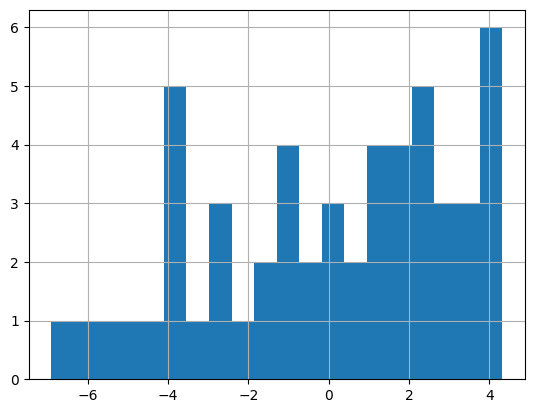

In [ ]:
#call BT Scores method
LLM_BT_scores, LLM_img2numID, LLM_bt_ranked_indicies = BT_scores_from_surveyJSON(Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26.json")

Code from here on is primarily LLM-generated, as it is mostly data analysis

Matched images: 53 | Spearman rank correlation: -0.764


,image,human_bt_score,llm_bt_score,bt_score_difference,human_quartile,category
39,Table.jpg,2.301688,-6.909045,-9.210733,Q4 (highest),Hard / other surfaces
6,Whiteboard.jpg,2.234540,-5.972933,-8.207472,Q4 (highest),Hard / other surfaces
49,Plastic bag.jpg,1.746507,-5.666020,-7.412527,Q4 (highest),Hard / other surfaces
13,Pavement_.jpg,-2.936455,3.846020,6.782474,Q1 (lowest),Outdoor objects & surfaces
46,Wall(6).jpg,-2.609942,3.936737,6.546679,Q1 (lowest),Outdoor objects & surfaces
0,Bark.jpg,-1.904542,4.244348,6.148890,Q1 (lowest),Outdoor objects & surfaces
16,Table(1).jpg,0.901747,-5.142446,-6.044193,Q3,Hard / other surfaces
32,Wall(2).jpg,-1.720408,3.894341,5.614749,Q1 (lowest),Outdoor objects & surfaces
8,Rock.jpg,-0.978019,4.320055,5.298074,Q1 (lowest),Outdoor objects & surfaces
45,Fishing line.jpg,1.458312,-3.738125,-5.196436,Q4 (highest),Hard / other surfaces


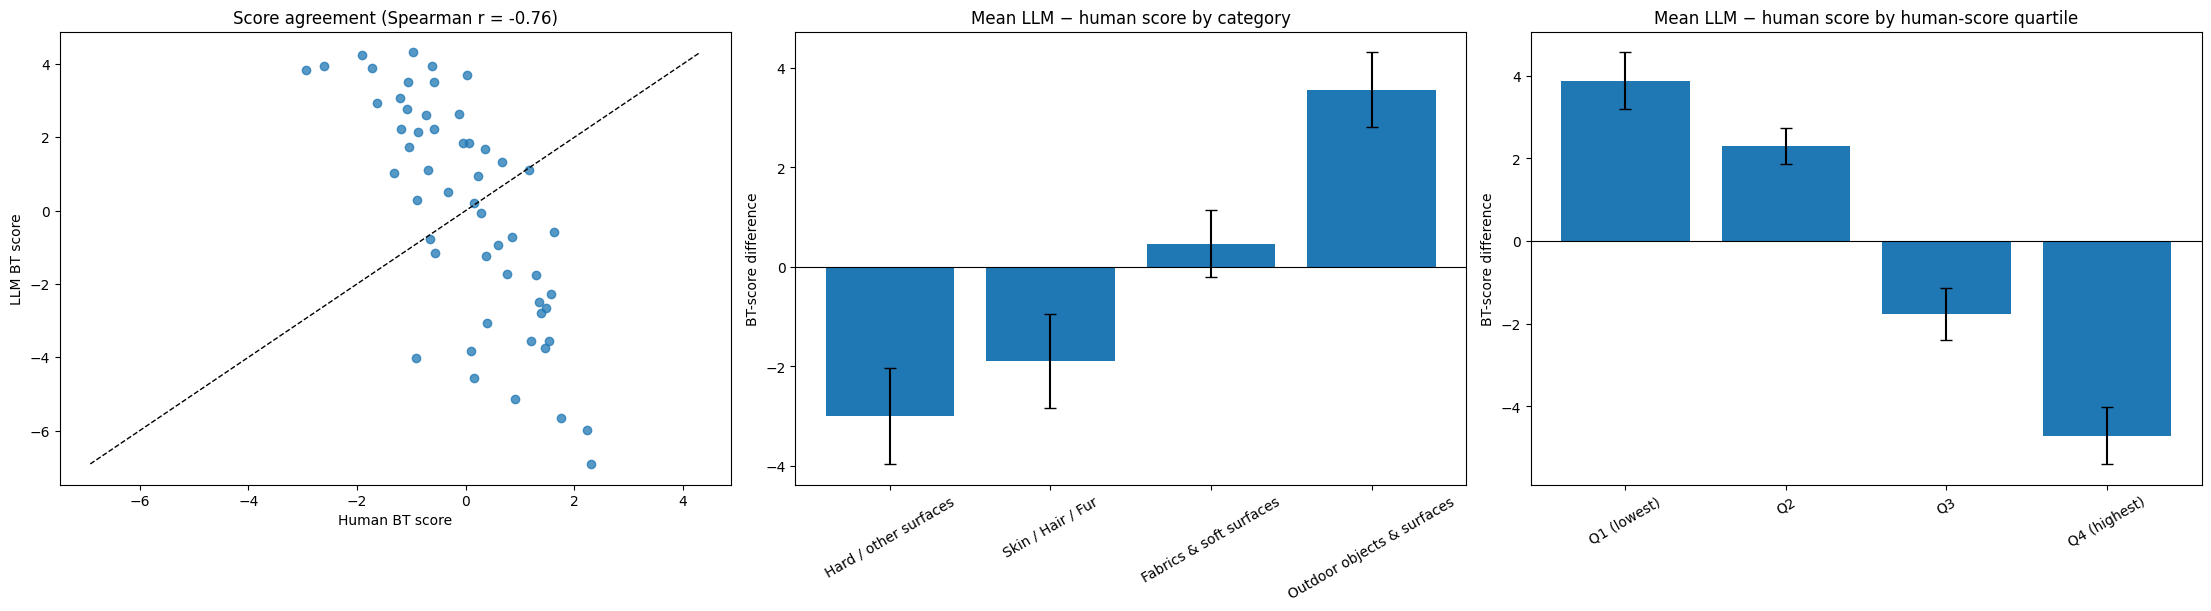

In [74]:
# Compare human and LLM Bradley-Terry scores by image name, never by array position.
# This assumes rank 1 has the same meaning in the human and LLM files.
import matplotlib.pyplot as plt

HUMAN_SURVEY_PATH = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
LLM_SURVEY_PATH = Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26.json"

def bt_scores_by_image(survey_path):
    """Fit BT scores without changing the source survey dictionaries."""
    with Path(survey_path).open(encoding="utf-8") as f:
        data = json.load(f)

    # Cell 16 writes a list; this also accepts eval_LLM_survey's wrapped output.
    surveys = data["ranked_images"] if isinstance(data, dict) else data
    image_names = list(dict.fromkeys(
        name for survey in surveys for name in survey if name != "index"
    ))
    image_to_id = {name: i for i, name in enumerate(image_names)}
    comparisons = []

    for survey in surveys:
        ranked = sorted(
            ((int(rank), name) for name, rank in survey.items() if name != "index"),
            key=lambda pair: pair[0],
        )
        ranks = [rank for rank, _ in ranked]
        if ranks != list(range(1, len(ranked) + 1)):
            raise ValueError(f"Invalid ranking in survey {survey.get('index')}: {ranks}")
        for winner_position, (_, winner) in enumerate(ranked):
            for _, loser in ranked[winner_position + 1:]:
                comparisons.append((image_to_id[winner], image_to_id[loser]))

    scores = choix.ilsr_pairwise(len(image_names), comparisons, alpha=0.01)
    return pd.Series(scores, index=image_names, name="bt_score")

human_scores = bt_scores_by_image(HUMAN_SURVEY_PATH)
llm_scores = bt_scores_by_image(LLM_SURVEY_PATH)
comparison = pd.concat([
    human_scores.rename("human_bt_score"),
    llm_scores.rename("llm_bt_score"),
], axis=1, join="inner").reset_index(names="image")

missing_from_llm = human_scores.index.difference(llm_scores.index)
missing_from_humans = llm_scores.index.difference(human_scores.index)
if len(missing_from_llm) or len(missing_from_humans):
    print(f"Excluded unmatched images — human only: {list(missing_from_llm)}; LLM only: {list(missing_from_humans)}")

comparison["bt_score_difference"] = comparison["llm_bt_score"] - comparison["human_bt_score"]
comparison["human_quartile"] = pd.qcut(
    comparison["human_bt_score"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], duplicates="drop"
)

def surface_category(image_name):
    name = image_name.lower()
    if any(word in name for word in ["skin", "hair", "fur"]):
        return "Skin / Hair / Fur"
    if any(word in name for word in ["bark", "pavement", "rock", "sandpaper", "sidewalk", "wall", "wood"]):
        return "Outdoor objects & surfaces"
    if any(word in name for word in ["bed", "blanket", "carpet", "fabric", "leather", "pillowcase", "rope", "towel", "weave"]):
        return "Fabrics & soft surfaces"
    return "Hard / other surfaces"

comparison["category"] = comparison["image"].map(surface_category)
spearman_r = comparison["human_bt_score"].corr(comparison["llm_bt_score"], method="spearman")
print(f"Matched images: {len(comparison)} | Spearman rank correlation: {spearman_r:.3f}")
display(comparison.sort_values("bt_score_difference", key=lambda x: x.abs(), ascending=False))

category_summary = comparison.groupby("category", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"]).sort_values("mean")
quartile_summary = comparison.groupby("human_quartile", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
axes[0].scatter(comparison["human_bt_score"], comparison["llm_bt_score"], alpha=0.75)
limits = [comparison[["human_bt_score", "llm_bt_score"]].min().min(), comparison[["human_bt_score", "llm_bt_score"]].max().max()]
axes[0].plot(limits, limits, "k--", linewidth=1)
axes[0].set(xlabel="Human BT score", ylabel="LLM BT score", title=f"Score agreement (Spearman r = {spearman_r:.2f})")

for ax, summary, title in [(axes[1], category_summary, "Mean LLM − human score by category"), (axes[2], quartile_summary, "Mean LLM − human score by human-score quartile")]:
    ax.bar(summary.index.astype(str), summary["mean"], yerr=summary["sem"].fillna(0), capsize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=title, ylabel="BT-score difference")
    ax.tick_params(axis="x", rotation=30)

plt.show()
comparison.to_csv(Path("..") / "data" / "human_llm_bt_score_comparison.csv", index=False)


Matched images: 53 | Spearman rank correlation: 0.784


,image,human_bt_score,llm_bt_score,bt_score_difference,human_quartile,category
8,Rock.jpg,-0.978019,-7.120269,-6.142250,Q1 (lowest),Outdoor objects & surfaces
18,Pavement.jpg,-0.627226,-5.289287,-4.662061,Q2,Outdoor objects & surfaces
0,Bark.jpg,-1.904542,-6.526258,-4.621716,Q1 (lowest),Outdoor objects & surfaces
22,Fan vent.jpg,-0.908662,3.454622,4.363284,Q1 (lowest),Hard / other surfaces
25,Hair(2).jpg,0.030969,-4.080462,-4.111431,Q2,Skin / Hair / Fur
26,Water bottle.jpg,0.151812,3.837066,3.685254,Q3,Hard / other surfaces
30,Hair.jpg,0.094724,3.388748,3.294024,Q3,Skin / Hair / Fur
12,Styrofoam_.jpg,-0.579899,-3.864788,-3.284889,Q2,Hard / other surfaces
32,Wall(2).jpg,-1.720408,-4.954330,-3.233922,Q1 (lowest),Outdoor objects & surfaces
7,Wooden sign.jpg,-1.063813,-4.210309,-3.146496,Q1 (lowest),Outdoor objects & surfaces


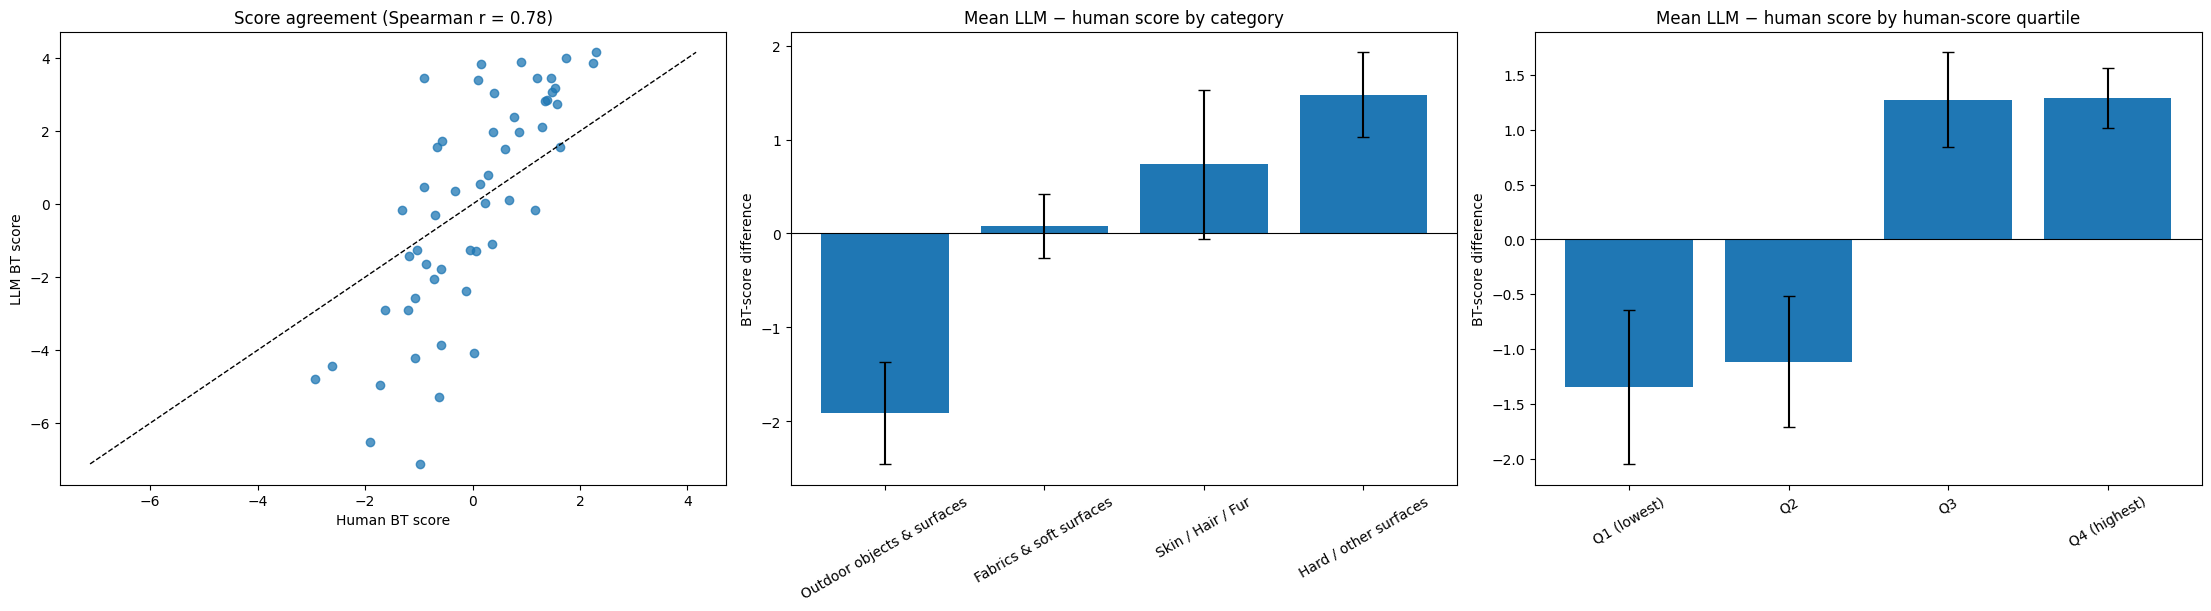

In [75]:
# Compare human and LLM Bradley-Terry scores by image name, never by array position.
# The human survey uses rank 1 = smoothest, while the LLM prompt uses rank 1 = roughest.
import matplotlib.pyplot as plt

HUMAN_SURVEY_PATH = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
LLM_SURVEY_PATH = Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26.json"

def bt_scores_by_image(survey_path, reverse_ranks=False):
    """Fit BT scores without changing the source survey dictionaries."""
    with Path(survey_path).open(encoding="utf-8") as f:
        data = json.load(f)

    # Cell 16 writes a list; this also accepts eval_LLM_survey's wrapped output.
    surveys = data["ranked_images"] if isinstance(data, dict) else data
    image_names = list(dict.fromkeys(
        name for survey in surveys for name in survey if name != "index"
    ))
    image_to_id = {name: i for i, name in enumerate(image_names)}
    comparisons = []

    for survey in surveys:
        ranked = sorted(
            ((int(rank), name) for name, rank in survey.items() if name != "index"),
            key=lambda pair: pair[0],
        )
        ranks = [rank for rank, _ in ranked]
        if ranks != list(range(1, len(ranked) + 1)):
            raise ValueError(f"Invalid ranking in survey {survey.get('index')}: {ranks}")
        if reverse_ranks:
            ranked = sorted(((len(ranked) + 1 - rank, name) for rank, name in ranked), key=lambda pair: pair[0])
        for winner_position, (_, winner) in enumerate(ranked):
            for _, loser in ranked[winner_position + 1:]:
                comparisons.append((image_to_id[winner], image_to_id[loser]))

    scores = choix.ilsr_pairwise(len(image_names), comparisons, alpha=0.01)
    return pd.Series(scores, index=image_names, name="bt_score")

human_scores = bt_scores_by_image(HUMAN_SURVEY_PATH)
llm_scores = bt_scores_by_image(LLM_SURVEY_PATH, reverse_ranks=True)
comparison = pd.concat([
    human_scores.rename("human_bt_score"),
    llm_scores.rename("llm_bt_score"),
], axis=1, join="inner").reset_index(names="image")

missing_from_llm = human_scores.index.difference(llm_scores.index)
missing_from_humans = llm_scores.index.difference(human_scores.index)
if len(missing_from_llm) or len(missing_from_humans):
    print(f"Excluded unmatched images — human only: {list(missing_from_llm)}; LLM only: {list(missing_from_humans)}")

comparison["bt_score_difference"] = comparison["llm_bt_score"] - comparison["human_bt_score"]
comparison["human_quartile"] = pd.qcut(
    comparison["human_bt_score"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], duplicates="drop"
)

def surface_category(image_name):
    name = image_name.lower()
    if any(word in name for word in ["skin", "hair", "fur"]):
        return "Skin / Hair / Fur"
    if any(word in name for word in ["bark", "pavement", "rock", "sandpaper", "sidewalk", "wall", "wood"]):
        return "Outdoor objects & surfaces"
    if any(word in name for word in ["bed", "blanket", "carpet", "fabric", "leather", "pillowcase", "rope", "towel", "weave"]):
        return "Fabrics & soft surfaces"
    return "Hard / other surfaces"

comparison["category"] = comparison["image"].map(surface_category)
spearman_r = comparison["human_bt_score"].corr(comparison["llm_bt_score"], method="spearman")
print(f"Matched images: {len(comparison)} | Spearman rank correlation: {spearman_r:.3f}")
display(comparison.sort_values("bt_score_difference", key=lambda x: x.abs(), ascending=False))

category_summary = comparison.groupby("category", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"]).sort_values("mean")
quartile_summary = comparison.groupby("human_quartile", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
axes[0].scatter(comparison["human_bt_score"], comparison["llm_bt_score"], alpha=0.75)
limits = [comparison[["human_bt_score", "llm_bt_score"]].min().min(), comparison[["human_bt_score", "llm_bt_score"]].max().max()]
axes[0].plot(limits, limits, "k--", linewidth=1)
axes[0].set(xlabel="Human BT score", ylabel="LLM BT score", title=f"Score agreement (Spearman r = {spearman_r:.2f})")

for ax, summary, title in [(axes[1], category_summary, "Mean LLM − human score by category"), (axes[2], quartile_summary, "Mean LLM − human score by human-score quartile")]:
    ax.bar(summary.index.astype(str), summary["mean"], yerr=summary["sem"].fillna(0), capsize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=title, ylabel="BT-score difference")
    ax.tick_params(axis="x", rotation=30)

plt.show()
comparison.to_csv(Path("..") / "data" / "human_llm_bt_score_comparison.csv", index=False)


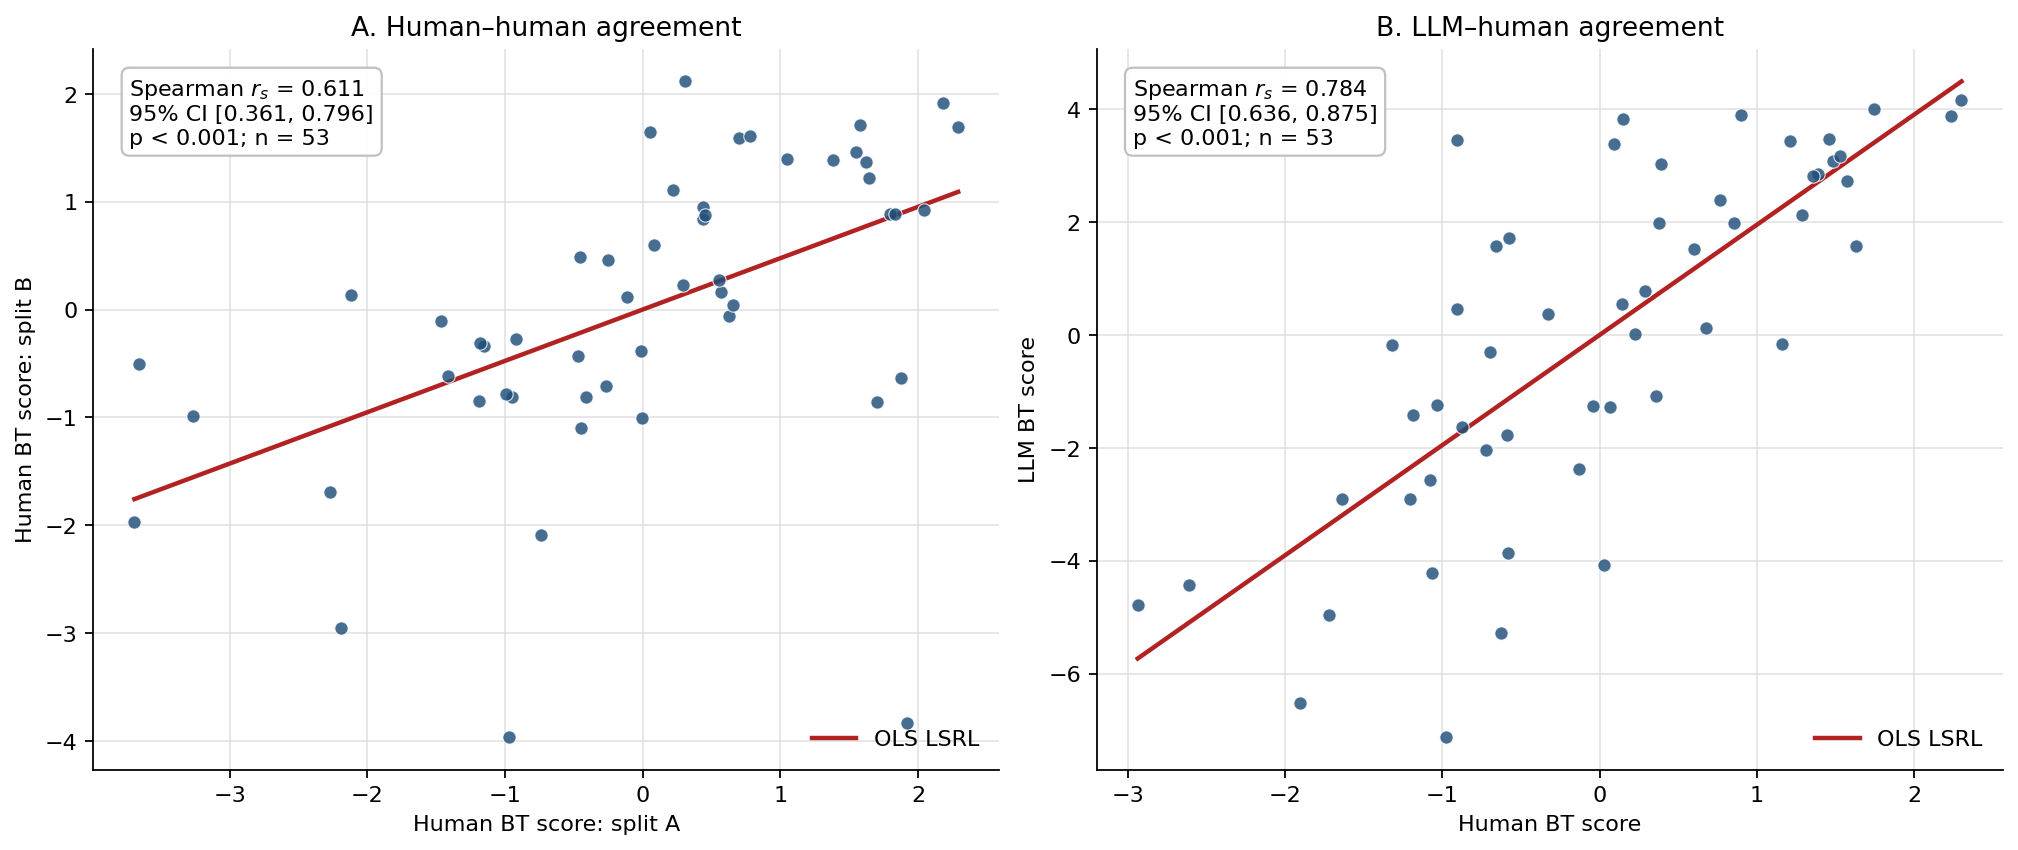

{'human_human': {'spearman_r': np.float64(0.6109498467989034),
  'spearman_ci_95': (np.float64(0.36099251580941527),
   np.float64(0.7955819533085368)),
  'spearman_p': np.float64(1.182802234830078e-06),
  'slope': np.float64(0.4760671787975859),
  'intercept': np.float64(4.149414026293938e-17),
  'n_images': 53},
 'llm_human': {'spearman_r': np.float64(0.7838251894855668),
  'spearman_ci_95': (np.float64(0.6355310556928327),
   np.float64(0.8746576084571073)),
  'spearman_p': np.float64(3.9247803857580756e-12),
  'slope': np.float64(1.9525074060215228),
  'intercept': np.float64(-6.06320071782912e-16),
  'n_images': 53}}

In [79]:
# Paper-style BT-score agreement plots.
def plot_bt_spearman_comparison(
    human_survey_path=None,
    llm_survey_path=None,
    human_split_seed=20260809,
    bootstrap_iterations=10_000,
):
    """Plot split-half human and human-LLM BT-score agreement.

    Human sessions are randomly split with a fixed seed. Spearman r measures
    ordinal agreement with a percentile-bootstrap 95% confidence interval;
    the plotted line is the ordinary least-squares LSRL.
    """
    from pathlib import Path
    import json
    import choix
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from scipy.stats import linregress, spearmanr

    human_survey_path = human_survey_path or Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
    llm_survey_path = llm_survey_path or Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26_smooth_to_rough.json"

    def load_survey_rows(path):
        with Path(path).open(encoding="utf-8") as f:
            data = json.load(f)
        return data["ranked_images"] if isinstance(data, dict) else data

    def fit_bt_scores(rows):
        image_names = list(dict.fromkeys(
            image for row in rows for image in row if image != "index"
        ))
        image_to_id = {image: i for i, image in enumerate(image_names)}
        comparisons = []
        for row in rows:
            ranked = sorted(((int(rank), image) for image, rank in row.items() if image != "index"), key=lambda pair: pair[0])
            if [rank for rank, _ in ranked] != list(range(1, len(ranked) + 1)):
                raise ValueError(f"Invalid ranks in survey {row.get('index')}.")
            for position, (_, winner) in enumerate(ranked):
                for _, loser in ranked[position + 1:]:
                    comparisons.append((image_to_id[winner], image_to_id[loser]))
        if not comparisons:
            raise ValueError("No pairwise comparisons were available to fit BT scores.")
        return pd.Series(choix.ilsr_pairwise(len(image_names), comparisons, alpha=0.01), index=image_names)

    def align_scores(x_scores, y_scores):
        paired = pd.concat([x_scores.rename("x"), y_scores.rename("y")], axis=1, join="inner").dropna()
        if len(paired) < 3:
            raise ValueError("At least three shared images are required for a scatterplot.")
        return paired

    def spearman_confidence_interval(x, y, random_generator):
        bootstrap_r = []
        for _ in range(bootstrap_iterations):
            sample = random_generator.integers(0, len(x), size=len(x))
            correlation = spearmanr(x[sample], y[sample]).statistic
            if np.isfinite(correlation):
                bootstrap_r.append(correlation)
        if len(bootstrap_r) < 100:
            raise ValueError("Too few valid bootstrap samples to calculate a Spearman confidence interval.")
        return np.percentile(bootstrap_r, [2.5, 97.5])

    def draw_agreement_panel(axis, paired, x_label, y_label, title, random_generator):
        x, y = paired["x"].to_numpy(), paired["y"].to_numpy()
        spearman_r, spearman_p = spearmanr(x, y)
        ci_low, ci_high = spearman_confidence_interval(x, y, random_generator)
        regression = linregress(x, y)
        x_line = np.linspace(x.min(), x.max(), 200)
        axis.scatter(x, y, s=36, color="#1f4e79", alpha=0.82, edgecolor="white", linewidth=0.5, zorder=3)
        axis.plot(x_line, regression.intercept + regression.slope * x_line, color="#b22222", linewidth=2, label="OLS LSRL", zorder=2)
        axis.set(title=title, xlabel=x_label, ylabel=y_label)
        axis.grid(True, color="#d9d9d9", linewidth=0.7, alpha=0.8, zorder=0)
        axis.spines[["top", "right"]].set_visible(False)
        p_label = "p < 0.001" if spearman_p < 0.001 else f"p = {spearman_p:.3f}"
        axis.text(0.04, 0.96, f"Spearman $r_s$ = {spearman_r:.3f}\n95% CI [{ci_low:.3f}, {ci_high:.3f}]\n{p_label}; n = {len(paired)}", transform=axis.transAxes, va="top", fontsize=10, bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#bdbdbd", "alpha": 0.95})
        axis.legend(frameon=False, loc="lower right")
        return {"spearman_r": spearman_r, "spearman_ci_95": (ci_low, ci_high), "spearman_p": spearman_p, "slope": regression.slope, "intercept": regression.intercept, "n_images": len(paired)}

    human_rows = load_survey_rows(human_survey_path)
    if len(human_rows) < 2:
        raise ValueError("At least two human ranking sessions are required for a split-half comparison.")
    shuffled_indices = np.random.default_rng(human_split_seed).permutation(len(human_rows))
    midpoint = len(human_rows) // 2
    human_a = fit_bt_scores([human_rows[i] for i in shuffled_indices[:midpoint]])
    human_b = fit_bt_scores([human_rows[i] for i in shuffled_indices[midpoint:]])
    human_all = fit_bt_scores(human_rows)
    llm_all = fit_bt_scores(load_survey_rows(llm_survey_path))

    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
    figure, axes = plt.subplots(1, 2, figsize=(12.5, 5.2), dpi=160, constrained_layout=True)
    bootstrap_rng = np.random.default_rng(human_split_seed + 1)
    human_human = draw_agreement_panel(axes[0], align_scores(human_a, human_b), "Human BT score: split A", "Human BT score: split B", "A. Human–human agreement", bootstrap_rng)
    llm_human = draw_agreement_panel(axes[1], align_scores(human_all, llm_all), "Human BT score", "LLM BT score", "B. LLM–human agreement", bootstrap_rng)
    plt.show()
    return {"human_human": human_human, "llm_human": llm_human}

plot_bt_spearman_comparison()


Matched images: 53 | Spearman rank correlation: 0.784


,image,human_bt_score,llm_bt_score,bt_score_difference,human_quartile,category
8,Rock.jpg,-0.978019,-7.120269,-6.142250,Q1 (lowest),Outdoor objects & surfaces
18,Pavement.jpg,-0.627226,-5.289287,-4.662061,Q2,Outdoor objects & surfaces
0,Bark.jpg,-1.904542,-6.526258,-4.621716,Q1 (lowest),Outdoor objects & surfaces
22,Fan vent.jpg,-0.908662,3.454622,4.363284,Q1 (lowest),Hard / other surfaces
25,Hair(2).jpg,0.030969,-4.080462,-4.111431,Q2,Skin / Hair / Fur
26,Water bottle.jpg,0.151812,3.837066,3.685254,Q3,Hard / other surfaces
30,Hair.jpg,0.094724,3.388748,3.294024,Q3,Skin / Hair / Fur
12,Styrofoam_.jpg,-0.579899,-3.864788,-3.284889,Q2,Hard / other surfaces
32,Wall(2).jpg,-1.720408,-4.954330,-3.233922,Q1 (lowest),Outdoor objects & surfaces
7,Wooden sign.jpg,-1.063813,-4.210309,-3.146496,Q1 (lowest),Outdoor objects & surfaces


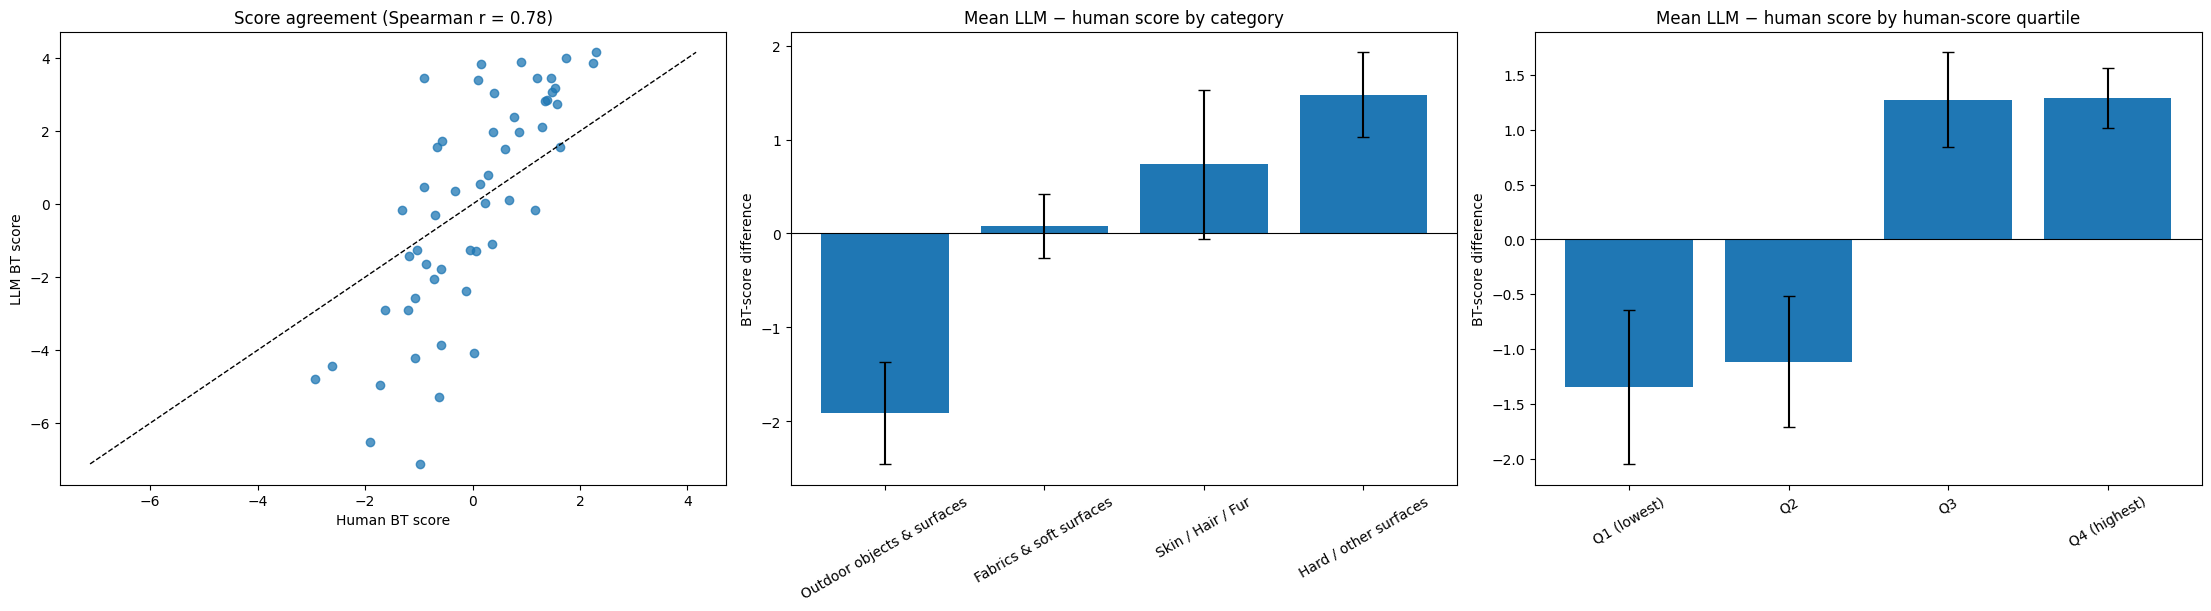

In [65]:
# Compare human and LLM Bradley-Terry scores by image name, never by array position.
# Important: confirm that rank 1 has the same meaning in the human and LLM files before interpreting this comparison.
import matplotlib.pyplot as plt

HUMAN_SURVEY_PATH = Path("..") / "data" / "Anonymized_Relative_Roughness_Survey_Results.json"
LLM_SURVEY_PATH = Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26.json"

def bt_scores_by_image(survey_path):
    """Fit BT scores without changing the source survey dictionaries."""
    with Path(survey_path).open(encoding="utf-8") as f:
        data = json.load(f)

    # Cell 16 writes a list; this also accepts eval_LLM_survey's wrapped output.
    surveys = data["ranked_images"] if isinstance(data, dict) else data
    image_names = list(dict.fromkeys(
        name for survey in surveys for name in survey if name != "index"
    ))
    image_to_id = {name: i for i, name in enumerate(image_names)}
    comparisons = []

    for survey in surveys:
        ranked = sorted(
            ((int(rank), name) for name, rank in survey.items() if name != "index"),
            key=lambda pair: pair[0],
        )
        ranks = [rank for rank, _ in ranked]
        if ranks != list(range(1, len(ranked) + 1)):
            raise ValueError(f"Invalid ranking in survey {survey.get('index')}: {ranks}")
        for winner_position, (_, winner) in enumerate(ranked):
            for _, loser in ranked[winner_position + 1:]:
                comparisons.append((image_to_id[winner], image_to_id[loser]))

    scores = choix.ilsr_pairwise(len(image_names), comparisons, alpha=0.01)
    return pd.Series(scores, index=image_names, name="bt_score")

human_scores = bt_scores_by_image(HUMAN_SURVEY_PATH)
llm_scores = bt_scores_by_image(LLM_SURVEY_PATH)
comparison = pd.concat([
    human_scores.rename("human_bt_score"),
    llm_scores.rename("llm_bt_score"),
], axis=1, join="inner").reset_index(names="image")

missing_from_llm = human_scores.index.difference(llm_scores.index)
missing_from_humans = llm_scores.index.difference(human_scores.index)
if len(missing_from_llm) or len(missing_from_humans):
    print(f"Excluded unmatched images — human only: {list(missing_from_llm)}; LLM only: {list(missing_from_humans)}")

comparison["bt_score_difference"] = comparison["llm_bt_score"] - comparison["human_bt_score"]
comparison["human_quartile"] = pd.qcut(
    comparison["human_bt_score"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], duplicates="drop"
)

def surface_category(image_name):
    name = image_name.lower()
    if any(word in name for word in ["skin", "hair", "fur"]):
        return "Skin / Hair / Fur"
    if any(word in name for word in ["bark", "pavement", "rock", "sandpaper", "sidewalk", "wall", "wood"]):
        return "Outdoor objects & surfaces"
    if any(word in name for word in ["bed", "blanket", "carpet", "fabric", "leather", "pillowcase", "rope", "towel", "weave"]):
        return "Fabrics & soft surfaces"
    return "Hard / other surfaces"

comparison["category"] = comparison["image"].map(surface_category)
spearman_r = comparison["human_bt_score"].corr(comparison["llm_bt_score"], method="spearman")
print(f"Matched images: {len(comparison)} | Spearman rank correlation: {spearman_r:.3f}")
display(comparison.sort_values("bt_score_difference", key=lambda x: x.abs(), ascending=False))

category_summary = comparison.groupby("category", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"]).sort_values("mean")
quartile_summary = comparison.groupby("human_quartile", observed=True)["bt_score_difference"].agg(["mean", "sem", "count"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)
axes[0].scatter(comparison["human_bt_score"], comparison["llm_bt_score"], alpha=0.75)
limits = [comparison[["human_bt_score", "llm_bt_score"]].min().min(), comparison[["human_bt_score", "llm_bt_score"]].max().max()]
axes[0].plot(limits, limits, "k--", linewidth=1)
axes[0].set(xlabel="Human BT score", ylabel="LLM BT score", title=f"Score agreement (Spearman r = {spearman_r:.2f})")

for ax, summary, title in [(axes[1], category_summary, "Mean LLM − human score by category"), (axes[2], quartile_summary, "Mean LLM − human score by human-score quartile")]:
    ax.bar(summary.index.astype(str), summary["mean"], yerr=summary["sem"].fillna(0), capsize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set(title=title, ylabel="BT-score difference")
    ax.tick_params(axis="x", rotation=30)

plt.show()
comparison.to_csv(Path("..") / "data" / "human_llm_bt_score_comparison.csv", index=False)


Bradley-Terry Scores: [ 4.244  1.852  0.215 -0.712 -3.067  4.32   3.519  2.932  1.016 -5.973
  3.517  1.73  -0.927  3.846  1.679  1.103  3.951  2.136 -5.142  2.783
  0.948 -2.666  2.24   0.294 -4.014  3.695 -4.557  1.846 -0.787 -3.543
 -3.831  3.894  2.634 -1.147 -2.794 -1.739 -0.584 -2.486 -1.755 -6.909
  2.229 -1.231 -0.068  2.61   1.115 -3.738  3.937  3.068  0.496 -5.666
  1.324 -2.279 -3.56 ]

 proportion of images receiveing scores:  1.0
Final Ranking (Best to Worst): ['Rock.jpg', 'Bark.jpg', 'Pavement.jpg', 'Wall(6).jpg', 'Wall(2).jpg', 'Pavement_.jpg', 'Hair(2).jpg', 'Wooden sign.jpg', 'Styrofoam_.jpg', 'Wood(1).jpg', 'Wall(5).jpg', 'Wall(1).jpg', 'Wall(3).jpg', 'Carpet.jpg', 'Towel.jpg', 'Sandpaper.jpg', 'Sidewalk.jpg', 'Wall(4).jpg', 'Bed headboard fabric_.jpg', 'Rope.jpg', 'Towel(1).jpg', 'Blanket.jpg', 'Graphite drawing.jpg', 'Weave bag(1).jpg', 'Clay sculpture_.jpg', 'Fabric.jpg', 'Pillowcase fabric_.jpg', 'Fan vent(1).jpg', 'Leather chair.jpg', 'Table(2).jpg', 'Stuffed ani

(array([ 4.24434778,  1.85198238,  0.21509087, -0.71244327, -3.06701277,
         4.32005488,  3.51882648,  2.93171085,  1.01610128, -5.97293268,
         3.51733495,  1.72987048, -0.92660962,  3.84601963,  1.67870571,
         1.10296657,  3.95070185,  2.1360113 , -5.14244588,  2.78321327,
         0.94844224, -2.66626257,  2.24030763,  0.29400894, -4.01378086,
         3.69498277, -4.55672795,  1.84595209, -0.78659132, -3.54261414,
        -3.83078488,  3.89434137,  2.63359104, -1.14709627, -2.79358411,
        -1.73869673, -0.58417948, -2.4855282 , -1.75470329, -6.90904502,
         2.22852339, -1.2305223 , -0.06803582,  2.61025169,  1.11451545,
        -3.73812458,  3.93673714,  3.06820313,  0.49569359, -5.66601963,
         1.32358679, -2.2785596 , -3.55977459]),
 {'Bark.jpg': 0,
  'Wall(4).jpg': 1,
  'Leather chair.jpg': 2,
  'Skin.png': 3,
  'Skin(1).jpg': 4,
  'Rock.jpg': 5,
  'Wooden sign.jpg': 6,
  'Wall(5).jpg': 7,
  'Clay sculpture_.jpg': 8,
  'Whiteboard.jpg': 9,
  'Styrof

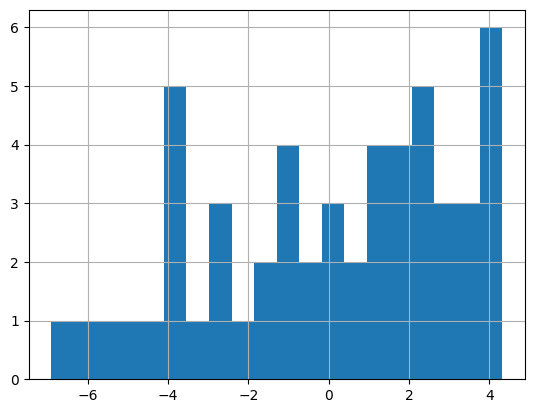

In [ ]:
# Convert the LLM convention (1 = roughest) to the human-survey convention (1 = smoothest).
# A new file is written so the original LLM response remains unchanged.
def reverse_llm_survey_ranks(input_path, output_path):
    with Path(input_path).open(encoding="utf-8") as f:
        data = json.load(f)

    # Accept either the list written by cell 16 or eval_LLM_survey's wrapped output.
    rows = data["ranked_images"] if isinstance(data, dict) else data
    reversed_rows = []

    for row in rows:
        image_ranks = {name: int(rank) for name, rank in row.items() if name != "index"}
        n_images = len(image_ranks)
        expected_ranks = list(range(1, n_images + 1))
        if sorted(image_ranks.values()) != expected_ranks:
            raise ValueError(f"Invalid ranks in survey {row.get('index')}: {image_ranks}")

        reversed_row = {"index": int(row["index"])}
        reversed_row.update({name: n_images + 1 - rank for name, rank in image_ranks.items()})
        reversed_rows.append(reversed_row)

    with Path(output_path).open("w", encoding="utf-8") as f:
        json.dump(reversed_rows, f, indent=2)

    print(f"Wrote {len(reversed_rows)} reversed LLM survey rows to {output_path}")
    return reversed_rows

LLM_REVERSED_SURVEY_PATH = Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26_smooth_to_rough.json"
reverse_llm_survey_ranks(
    Path("..") / "data" / "LLM_Ranked_Survey_Results_Gemma_8_8_26.json",
    LLM_REVERSED_SURVEY_PATH,
)
